# 🚀 Soft Margin Support Vector Machine (SVM) In-Depth Guide

## 1. 📐 Intuition and Working of Soft Margin SVM

**The Problem with Hard Margin:**
Imagine you have a group of red circles and blue squares that you want to separate with a line. A Hard Margin SVM demands a perfect split with absolutely no data points inside the margin. 
However, real-world data is almost never perfect. What if one red circle is accidentally mixed in with the blue squares? 
- A Hard Margin SVM would either fail to find any line at all, or it would draw a severely distorted, narrow boundary just to accommodate that single outlier. This is called **"overfitting."**

**The Soft Margin Solution:**
A Soft Margin SVM accepts that data is messy. It says, *"I want the widest street (margin) possible, but I will allow a few cars (data points) to drive on the sidewalk or even on the wrong side of the street if it helps the overall street be wider and straighter."*

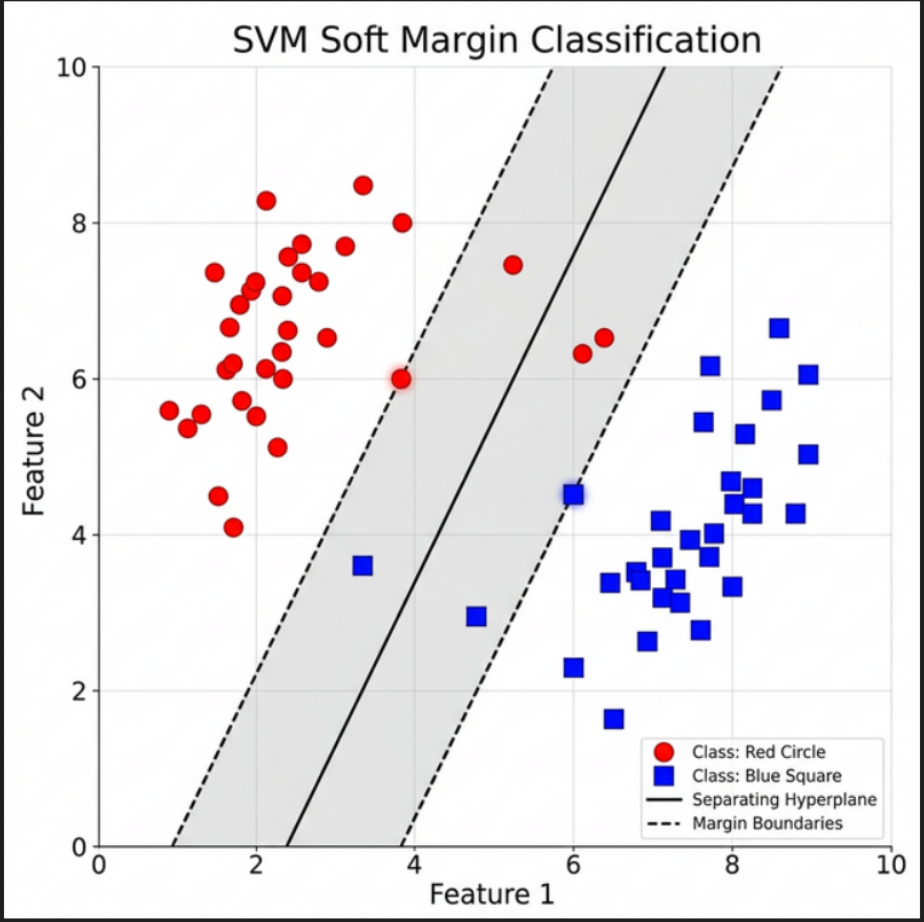

It does this by introducing a concept called a **"Slack Variable" ($\zeta$)**. For every single data point, the model calculates a slack value. 
- If the point is safely outside the margin on the correct side, its slack is `0`. 
- If the point is inside the margin or on the totally wrong side of the line, its slack is greater than `0`.

The SVM now has two competing goals:
1. Make the margin as wide as possible.
2. Keep the sum of all the errors (the slack) as small as possible.

To balance these two goals, we use a hyperparameter called **`C`**.
- **High `C`:** The model is very strict. It heavily penalizes errors, leading to a narrower margin but fewer misclassifications (acts more like a Hard Margin).
- **Low `C`:** The model is very relaxed. It allows more errors in order to draw a wider, more general margin.

## 2. 🧮 The Mathematics of Soft Margin SVM

**The Linear Hyperplane:**
Just like in basic SVM, the equation of the line is defined by weights ($w$) and a bias ($b$).
* **Line Equation:** $w^T x + b = 0$
* **Positive Boundary:** $w^T x + b = 1$
* **Negative Boundary:** $w^T x + b = -1$

**Introducing the Slack Variable ($\zeta$):**
For a Hard Margin, the strict rule for every data point $i$ with an actual answer $y_i$ (where $y_i$ is either $1$ or $-1$) was:
$$y_i (w^T x_i + b) \geq 1$$

For a Soft Margin, we add the slack variable ($\zeta_i$) to give the model some breathing room. $\zeta_i$ is always $\geq 0$. 
The new constraint rule becomes:
$$y_i (w^T x_i + b) \geq 1 - \zeta_i$$

What $\zeta_i$ means for a data point:
- **If $\zeta_i = 0$:** The point is totally safe. It is correctly classified and outside the margin.
- **If $0 < \zeta_i \leq 1$:** The point is correctly classified, but it is stuck inside the margin (on the sidewalk).
- **If $\zeta_i > 1$:** The point is misclassified (on the wrong side of the boundary line).

**The Final Mathematical Objective:**
In a Hard Margin, our only goal was to make the margin as wide as possible. Since margin width is $\frac{2}{||w||}$, we maximized it by minimizing the weight vector:
**Minimize:** $\frac{1}{2} ||w||^2$

In a Soft Margin, we must also minimize the total amount of slack (errors) we allowed, controlled by the penalty parameter $C$. 

**The new Soft Margin Objective Function is:**
$$ \text{Minimize:} \quad \frac{1}{2} ||w||^2 \; + \; C \sum_{i=1}^{n} \zeta_i $$

**Subject to the rules:**
$$ y_i (w^T x_i + b) \geq 1 - \zeta_i \quad \text{and} \quad \zeta_i \geq 0 $$

**How the math uses `C`:**
Look at the objective function above. 
- If you set **`C = 10000`**, the $C \sum \zeta_i$ part of the math becomes huge if there are any errors. The algorithm will force $\zeta_i$ to be $0$ to keep the total number small, creating a Hard Margin.
- If you set **`C = 0.01`**, the $C \sum \zeta_i$ part is very small. The algorithm won't care if $\zeta_i$ is large, and it will focus entirely on minimizing $||w||$ to make the margin as wide as possible.